In [98]:
import tensorflow as tf
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_curve, auc
from sklearn.utils import class_weight
from sklearn.manifold import TSNE
import torch

from tf_explain.core.grad_cam import GradCAM
import sys
import os

import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import seaborn as sns
import cv2

In [66]:
# Define standard parameters
IMG_SIZE = (224, 224) # Standard for most pre-trained models
BATCH_SIZE = 32

# Load the training data
train_data = tf.keras.utils.image_dataset_from_directory(
    'kalahari_classification_dataset/train',
    label_mode='categorical',
    shuffle=False,
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

species_list = train_data.class_names

# Load the validation data
val_data = tf.keras.utils.image_dataset_from_directory(
    'kalahari_classification_dataset/val',
    label_mode='categorical',
    shuffle=False, # No need to shuffle validation data
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

print(len(species_list))

Found 1140 files belonging to 22 classes.
Found 142 files belonging to 30 classes.
22


In [67]:
train_labels = np.concatenate([y for x, y in train_data], axis=0)
if len(train_labels.shape) > 1: # if categorical
    train_labels = np.argmax(train_labels, axis=1)

# 2. Calculate weights (higher weight for classes with fewer images)
weights = class_weight.compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_labels),
    y=train_labels
)

# 3. Turn into a dictionary {class_index: weight}
class_weight_dict = dict(enumerate(weights))

In [68]:
# 1. Load a pre-trained base (without the top layer)
base_model = tf.keras.applications.EfficientNetV2B1(weights='imagenet', include_top=False)
base_model.trainable = False  # Freeze it first


In [69]:
data_augmentation = tf.keras.Sequential([
  tf.keras.layers.RandomFlip("horizontal_and_vertical"),
  tf.keras.layers.RandomRotation(0.2),
  tf.keras.layers.RandomZoom(0.2),
  tf.keras.layers.RandomContrast(0.2),
])

# Add it to your model
model = tf.keras.Sequential([
    data_augmentation,
    base_model,
    tf.keras.layers.GlobalAveragePooling2D(),
    tf.keras.layers.Dense(len(species_list), activation='softmax')
])

In [70]:

# 3. Train the head (Phase 1)
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss='categorical_crossentropy')
model.fit(train_data, epochs=10)



Epoch 1/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 31s 593ms/step - loss: 3.0455
Epoch 2/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 22s 607ms/step - loss: 1.3782
Epoch 3/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 635ms/step - loss: 1.2644
Epoch 4/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 635ms/step - loss: 1.0676
Epoch 5/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 24s 666ms/step - loss: 0.9374
Epoch 6/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 28s 781ms/step - loss: 0.8605
Epoch 7/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 24s 667ms/step - loss: 0.7975
Epoch 8/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 27s 742ms/step - loss: 0.7474
Epoch 9/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 724ms/step - loss: 0.7139
Epoch 10/10
36/36 ━━━━━━━━━━━━━━━━━━━━ 24s 657ms/step - loss: 0.6963


In [71]:
# 4. Fine-tune the base (Phase 2)
base_model.trainable = True
# Only unfreeze the last 20 layers
for layer in base_model.layers[:-20]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.00001), loss='categorical_crossentropy')
model.fit(train_data, epochs=30, 
        #   class_weight=class_weight_dict
          )

Epoch 1/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 36s 736ms/step - loss: 2.7500
Epoch 2/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 690ms/step - loss: 2.6629
Epoch 3/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 24s 672ms/step - loss: 2.6159
Epoch 4/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 24s 681ms/step - loss: 2.5780
Epoch 5/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 723ms/step - loss: 2.5082
Epoch 6/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 703ms/step - loss: 2.4622
Epoch 7/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 725ms/step - loss: 2.4045
Epoch 8/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 723ms/step - loss: 2.3500
Epoch 9/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 24s 655ms/step - loss: 2.3287
Epoch 10/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 687ms/step - loss: 2.2831
Epoch 11/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 694ms/step - loss: 2.2328
Epoch 12/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 24s 655ms/step - loss: 2.2089
Epoch 13/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 719ms/step - loss: 2.1644
Epoch 14/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 724ms/step - loss: 2.1507
Epoch 15/30
36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 

In [72]:
test_data = tf.keras.utils.image_dataset_from_directory(
    'kalahari_classification_dataset/test',
    label_mode='categorical',
    shuffle=False, # No need to shuffle validation data
    batch_size=BATCH_SIZE,
    image_size=IMG_SIZE
)

Found 146 files belonging to 23 classes.


In [73]:
y_true_categorical = np.concatenate([y for x, y in test_data], axis=0)

y_true = np.argmax(y_true_categorical, axis=1)

predictions = model.predict(test_data)
y_pred = np.argmax(predictions, axis=1)

test_species_names = test_data.class_names

print(classification_report(y_true, y_pred))

2026-03-09 13:17:47.228107: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 936ms/step
              precision    recall  f1-score   support

           1       0.82      1.00      0.90        69
           2       0.00      0.00      0.00         1
           3       0.50      1.00      0.67         1
           4       1.00      0.50      0.67        10
           6       1.00      1.00      1.00         4
           7       0.86      1.00      0.92        18
           8       1.00      1.00      1.00         1
           9       0.00      0.00      0.00         1
          10       1.00      0.69      0.82        26
          11       1.00      1.00      1.00         1
          12       0.00      0.00      0.00         3
          13       0.75      1.00      0.86         3
          15       0.00      0.00      0.00         2
          16       0.00      0.00      0.00         0
          17       0.00      0.00      0.00         1
          18       1.00      0.50      0.67         2
          19       1.00      0.67      0.8

/opt/anaconda3/envs/cameratrapenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/cameratrapenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/cameratrapenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()

/var/folders/q6/dh9_zk1x5m94wr74c96ngwf40000gn/T/ipykernel_97162/826890934.py:3: RuntimeWarning: invalid value encountered in divide
  cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]


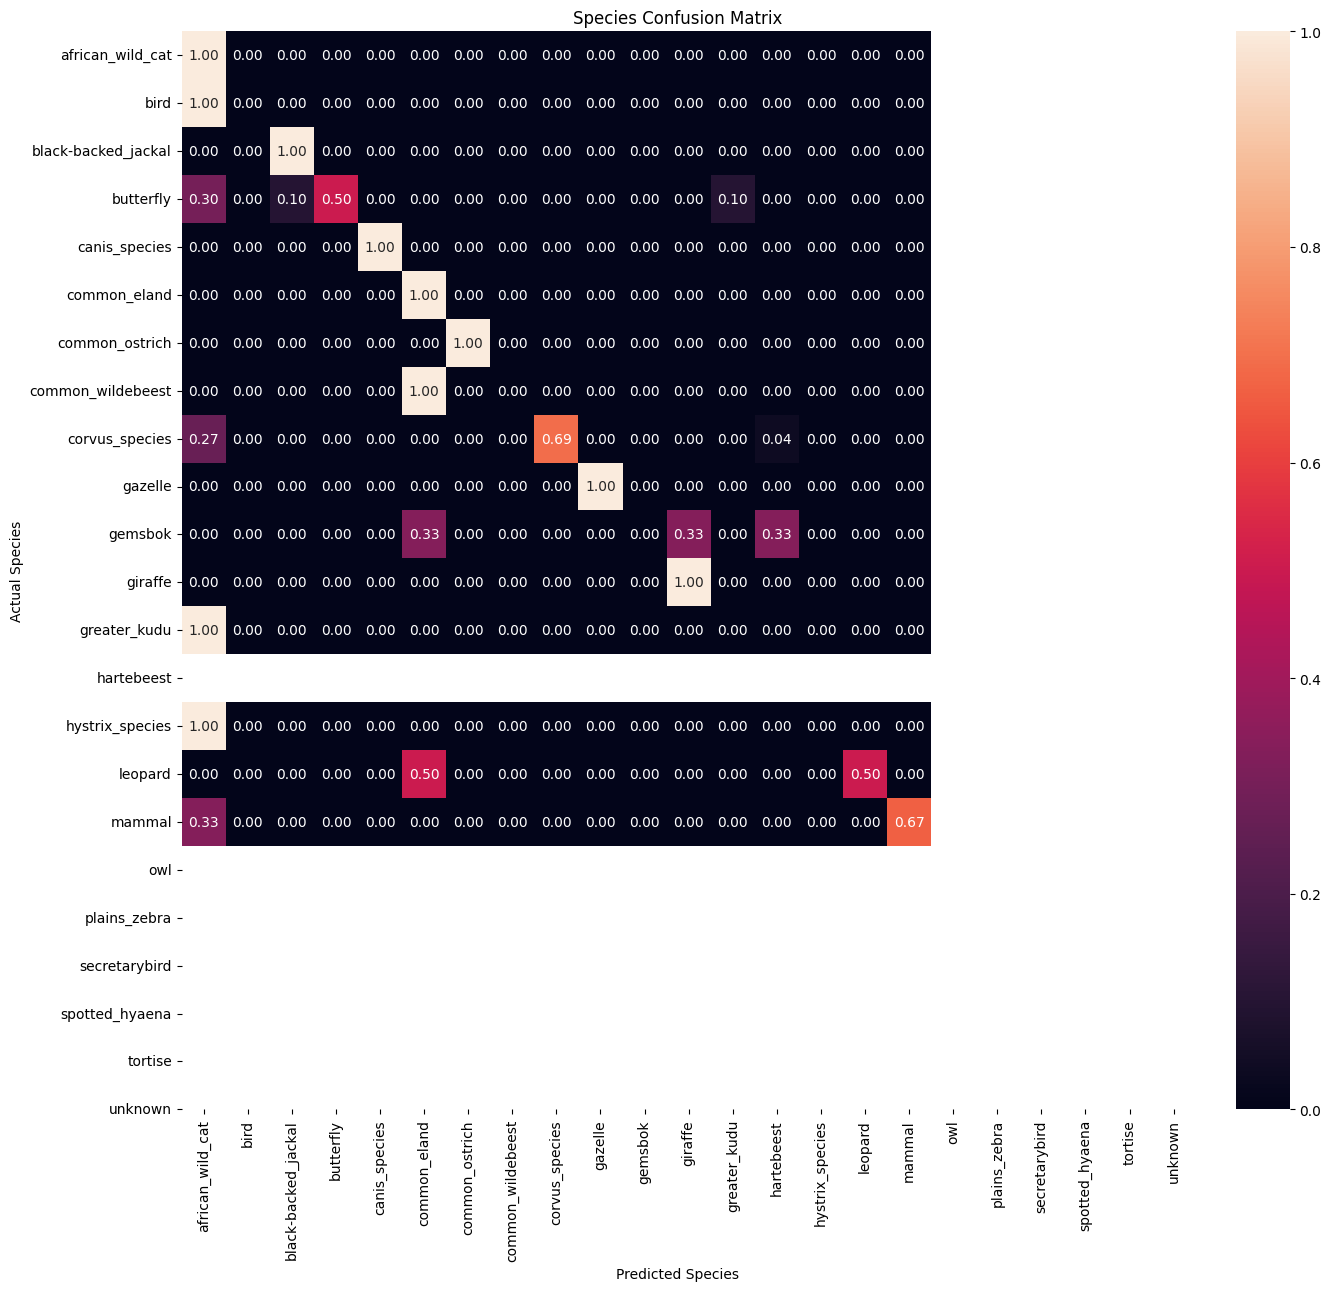

In [74]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2f', xticklabels=test_species_names, yticklabels=test_species_names)
plt.xlabel('Predicted Species')
plt.ylabel('Actual Species')
plt.title('Species Confusion Matrix')
plt.show()

In [75]:
acc = accuracy_score(y_true, y_pred)

print(f"Model Accuracy: {acc * 100:.2f}%")

Model Accuracy: 84.25%


In [76]:
print("Train classes:", train_data.class_names)
print("Test classes:", test_data.class_names)

Train classes: ['african_wild_cat', 'bird', 'black-backed_jackal', 'butterfly', 'canis_species', 'common_eland', 'common_ostrich', 'common_wildebeest', 'corvus_species', 'gazelle', 'gemsbok', 'giraffe', 'greater_kudu', 'hartebeest', 'hystrix_species', 'leopard', 'mammal', 'owl', 'plains_zebra', 'secretarybird', 'spotted_hyaena', 'unknown']
Test classes: ['african_wild_cat', 'bird', 'black-backed_jackal', 'butterfly', 'canis_species', 'common_eland', 'common_ostrich', 'common_wildebeest', 'corvus_species', 'gazelle', 'gemsbok', 'giraffe', 'greater_kudu', 'hartebeest', 'hystrix_species', 'leopard', 'mammal', 'owl', 'plains_zebra', 'secretarybird', 'spotted_hyaena', 'tortise', 'unknown']


5/5 ━━━━━━━━━━━━━━━━━━━━ 6s 1s/step  


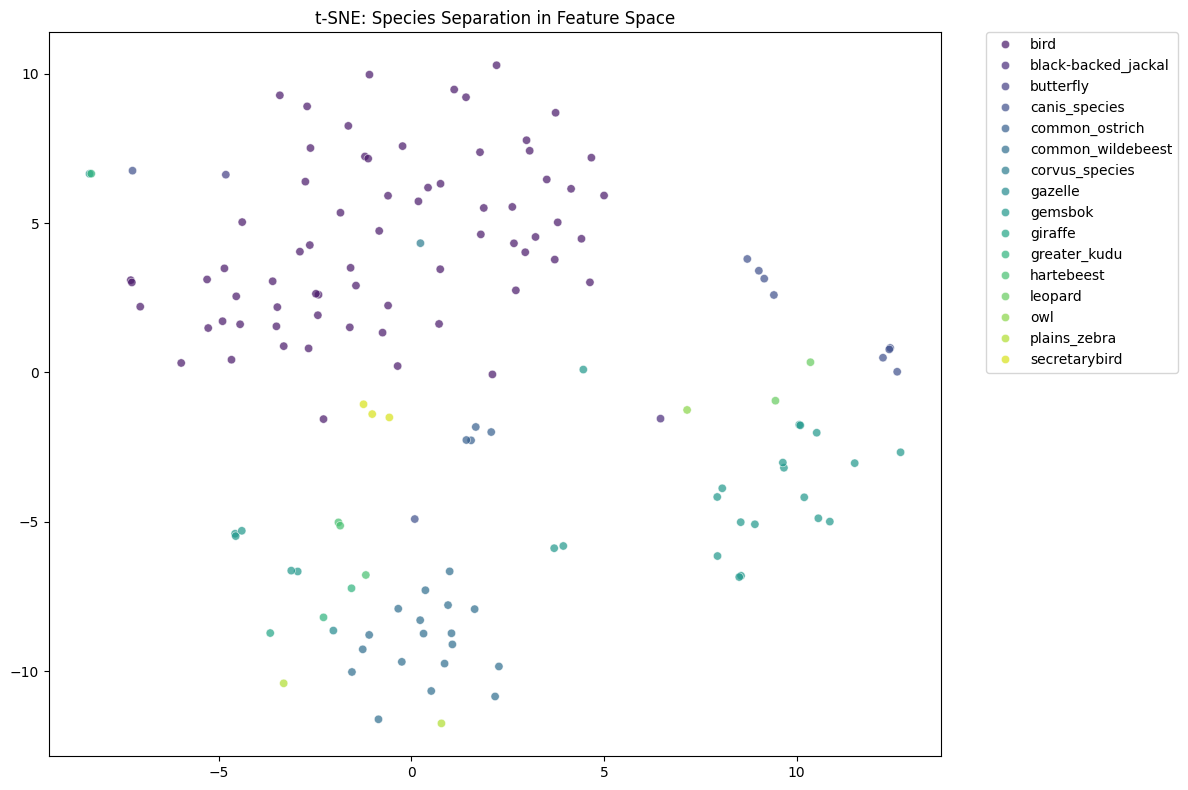

In [77]:
# 1. Create a "Feature Extractor" (the model minus the last Dense layer)
sample_images, _ = next(iter(test_data))
model(sample_images) 

# feature_extractor = tf.keras.Model(model.layers[:-2])

# 2. Get the "embeddings" (numerical fingerprints) for your 2,000 images
# embeddings = feature_extractor.predict(test_data)

input_shape = (224, 224, 3) 
x_input = tf.keras.Input(shape=input_shape)

# 2. Reconstruct the path through your model layers
# We iterate through all layers EXCEPT the last one (the classifier)
x = x_input
for layer in model.layers[:-1]:
    x = layer(x)

# 3. Create the feature extractor using this new explicit path
feature_extractor = tf.keras.Model(inputs=x_input, outputs=x)

# 4. Now run your prediction
# Ensure test_data images are resized to the same input_shape
embeddings = feature_extractor.predict(test_data)

# 3. Reduce 1280 dimensions down to 2 for plotting
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
reduced_data = tsne.fit_transform(embeddings)

y_true_labels = np.array(y_true).flatten()

# 2. Map the integer indices to the actual names
# We use a list comprehension to create a list of strings for Seaborn
hue_labels = [test_species_names[int(i)] for i in y_true_labels]

# 3. Plot using the mapped names
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=reduced_data[:, 0], 
    y=reduced_data[:, 1], 
    hue=hue_labels, 
    palette='viridis',
    legend='full',
    alpha=0.7
)

# 4. Clean up the legend (it can get crowded with 25 species)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
plt.title("t-SNE: Species Separation in Feature Space")
plt.tight_layout()
plt.show()

In [78]:
preds = model.predict(test_data)
pred_indices = np.argmax(preds, axis=1)

# Find indices where prediction != truth
errors = np.where(pred_indices != y_true)[0]

# 2. Sort by confidence (how sure was the model of its wrong answer?)
error_confidences = [preds[i][pred_indices[i]] for i in errors]
top_errors = errors[np.argsort(error_confidences)[-5:]]

5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 595ms/step


5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 380ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 2s 378ms/step


ValueError: num must be an integer with 1 <= num <= 5, not 6

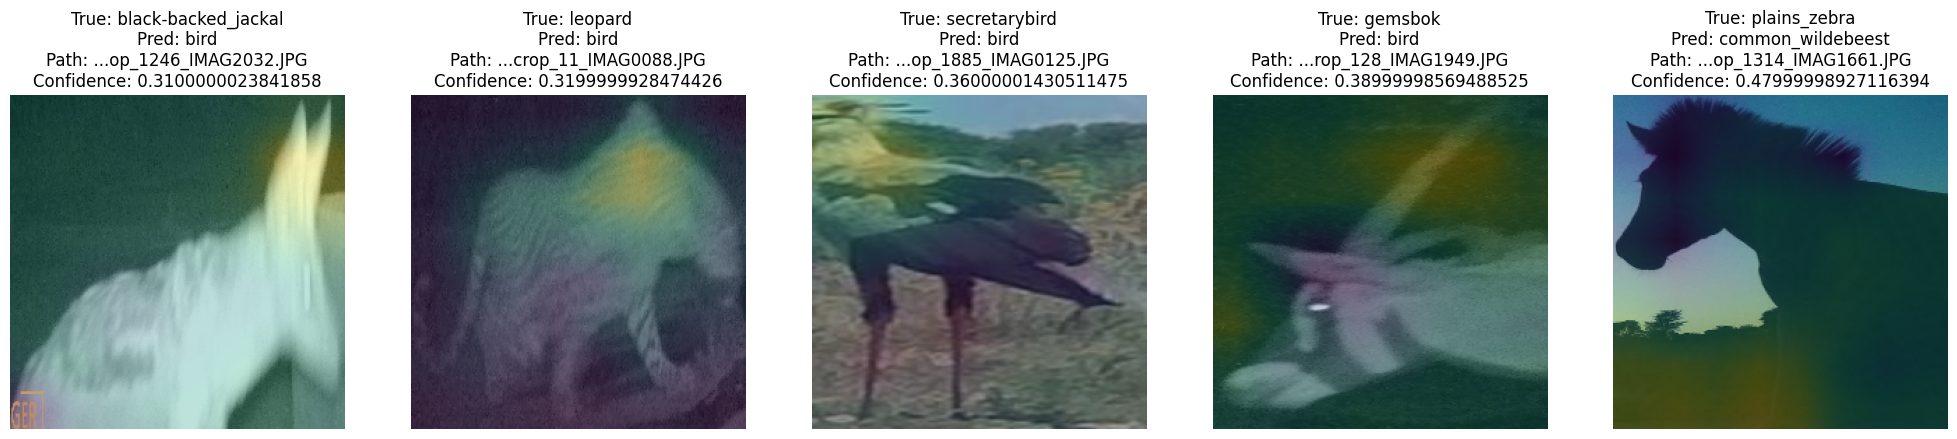

In [118]:
# 1. Setup the Explainer and Target Layer
explainer = GradCAM()
# Access the base model inside your Sequential wrapper
actual_base = model.get_layer("efficientnetv2-b1") 
# The last conv layer in EfficientNetV2 is usually "top_conv"
target_layer = "top_conv"

preds = model.predict(test_data)
pred_indices = np.argmax(preds, axis=1)

# Find indices where prediction != truth
errors = np.where(pred_indices != y_true)[0]

# 2. Sort by confidence (how sure was the model of its wrong answer?)
error_confidences = [preds[i][pred_indices[i]] for i in errors]
top_errors = errors[np.argsort(error_confidences)[-10:]]

all_filepaths = test_data.file_paths

# 2. Get your predictions (ensure these are for the whole test set)
predictions = model.predict(test_data)
pred_indices = np.argmax(predictions, axis=1)

# 3. Create a simple lookup function
def get_image_info(idx):
    path = all_filepaths[idx]
    actual_label = test_species_names[y_true[idx]]
    pred_label = test_species_names[pred_indices[idx]]
    confidence = np.max(predictions[idx])
    
    return path, actual_label, pred_label, confidence

errors = np.where(pred_indices != y_true)[0]

plt.figure(figsize=(25, 12))

for i, err_idx in enumerate(top_errors): # Just the first 5 errors
    path = all_filepaths[err_idx]
    true_name = test_species_names[y_true[err_idx]]
    pred_name = test_species_names[pred_indices[err_idx]]
    confidence = np.max(predictions[err_idx])

    raw_img = tf.io.read_file(path)
    img_tensor = tf.image.decode_image(raw_img, channels=3, expand_animations=False)
    img_tensor = tf.image.resize(img_tensor, (240, 240))
    
    # Add batch dimension and ensure float32
    input_batch = tf.expand_dims(img_tensor, axis=0)
    input_batch = tf.cast(input_batch, tf.float32)
    input_batch_np = input_batch.numpy()
    
    # --- STEP B: Generate Grad-CAM ---
    # We use the actual_base model here to avoid the "No such layer" error
    # class_index is the index of what the model PREDICTED (the wrong answer)
    heatmap_only = explainer.explain(
        validation_data=(input_batch_np, None),
        model=actual_base,
        layer_name=target_layer,
        class_index=pred_indices[err_idx], 
        image_weight=0 # Mix 40% original image, 60% heatmap
    )

    original_img = img_tensor.numpy().astype(np.uint8)

    # 3. Blend them manually: (Image * 0.7) + (Heatmap * 0.3) + 0_brightness_offset
    custom_blend = cv2.addWeighted(original_img, 0.7, heatmap_only, 0.3, 0)
    
    plt.subplot(1, 5, i+1)
    # img = mpimg.imread(path)
    plt.imshow(custom_blend)
    plt.title(f"True: {true_name}\nPred: {pred_name}\nPath: ...{path[-20:]}\nConfidence: {np.round(confidence, 2)}")
    plt.axis('off')

plt.show()

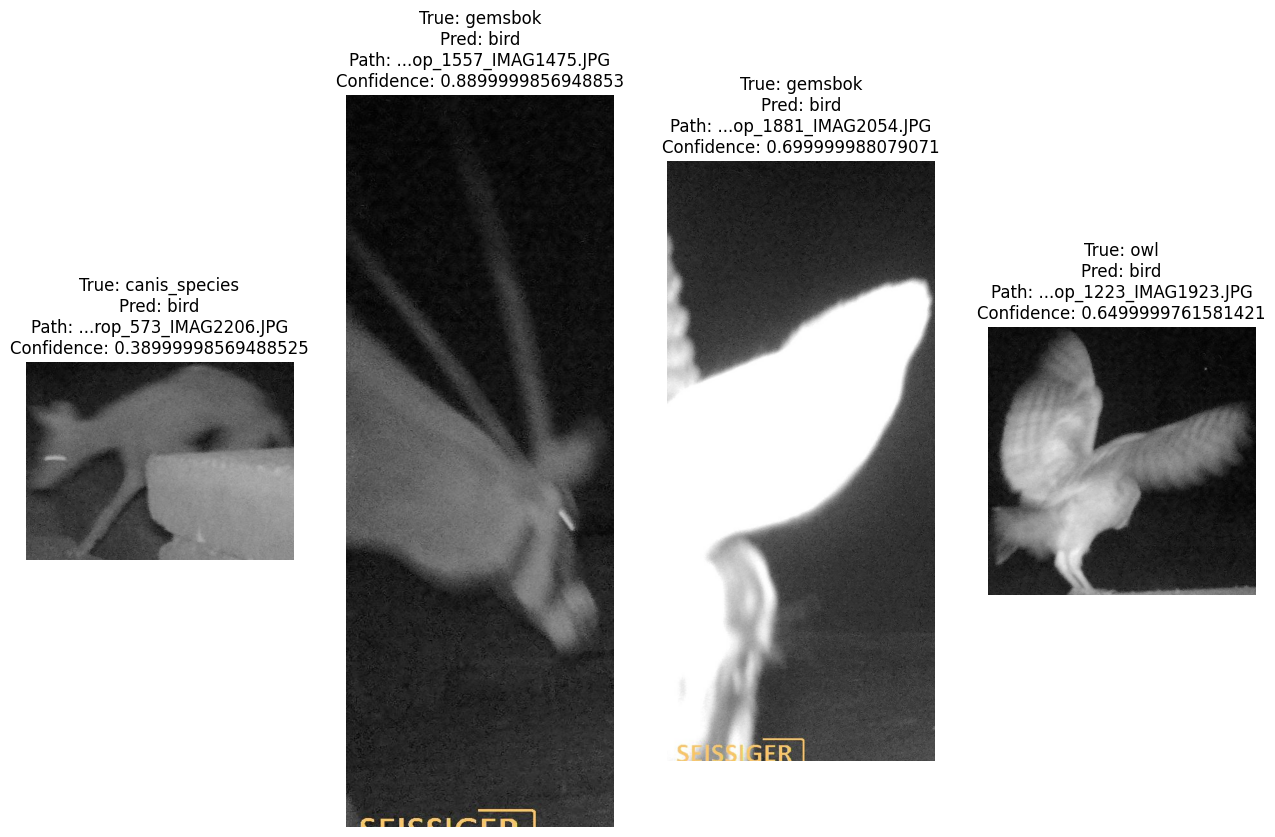

In [93]:
bottom_errors = errors[np.argsort(error_confidences)[18:23]]


plt.figure(figsize=(20, 10))

for i, err_idx in enumerate(bottom_errors): # Just the first 5 errors
    path = all_filepaths[err_idx]
    true_name = test_species_names[y_true[err_idx]]
    pred_name = test_species_names[pred_indices[err_idx]]
    confidence = np.max(predictions[err_idx])
    
    plt.subplot(1, 5, i+1)
    img = mpimg.imread(path)
    plt.imshow(img)
    plt.title(f"True: {true_name}\nPred: {pred_name}\nPath: ...{path[-20:]}\nConfidence: {np.round(confidence, 2)}")
    plt.axis('off')

plt.show()

In [81]:
def get_gradcam(img_array, model, last_conv_layer_name, pred_index):
    # 1. Create a model that outputs the last conv layer activations
    grad_model = tf.keras.models.Model(
        [model.inputs], [model.get_layer(last_conv_layer_name).output, model.output]
    )

    # 2. Compute the gradient of the predicted class with respect to the activations
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        loss = predictions[:, pred_index]

    # 3. Extract gradients and weight the feature map channels
    grads = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    heatmap = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # 4. Normalize for visualization
    heatmap = np.maximum(heatmap, 0) / np.max(heatmap)
    return heatmap

In [83]:
# 1. Get predictions on the TRAINING set (not the test set)
# Ensure shuffle=False so labels match file order
train_predictions = model.predict(train_data)
y_pred_train = np.argmax(train_predictions, axis=1)

# 2. Extract the true labels from the generator
y_true_raw = np.concatenate([y for x, y in train_data], axis=0)

# FIX: Convert the one-hot vectors into single integers (0, 1, 2...)
y_true_train = np.argmax(y_true_raw, axis=1)# If using sparse categorical crossentropy, y_true_train is already indices. 
# If one-hot, use: y_true_train = np.argmax(y_true_train, axis=1)

# 3. Calculate Accuracy
train_acc = accuracy_score(y_true_train, y_pred_train)
print(f"Custom Model Training Accuracy: {train_acc * 100:.2f}%")

# 4. Detailed Report
print(classification_report(y_true_train, y_pred_train, target_names=train_data.class_names))

36/36 ━━━━━━━━━━━━━━━━━━━━ 26s 587ms/step
Custom Model Training Accuracy: 84.47%
                     precision    recall  f1-score   support

   african_wild_cat       0.29      1.00      0.44         2
               bird       0.86      0.97      0.91       605
black-backed_jackal       1.00      0.67      0.80         3
          butterfly       0.86      0.80      0.83        15
      canis_species       0.72      0.72      0.72        47
       common_eland       0.33      0.33      0.33         6
     common_ostrich       0.89      1.00      0.94        31
  common_wildebeest       0.85      0.88      0.86        88
     corvus_species       0.86      0.19      0.32        31
            gazelle       1.00      1.00      1.00         1
            gemsbok       0.93      0.76      0.84       187
            giraffe       1.00      1.00      1.00        10
       greater_kudu       1.00      0.33      0.50         3
         hartebeest       0.90      0.68      0.78        28
   

/opt/anaconda3/envs/cameratrapenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/cameratrapenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/envs/cameratrapenv/lib/python3.10/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

In [84]:
raw_extractor = tf.keras.Sequential([
    base_model,
    tf.keras.layers.GlobalAveragePooling2D()
])

# Get "General" fingerprints
raw_embeddings = raw_extractor.predict(train_data)

custom_embeddings = feature_extractor.predict(train_data)

36/36 ━━━━━━━━━━━━━━━━━━━━ 25s 645ms/step
36/36 ━━━━━━━━━━━━━━━━━━━━ 23s 600ms/step


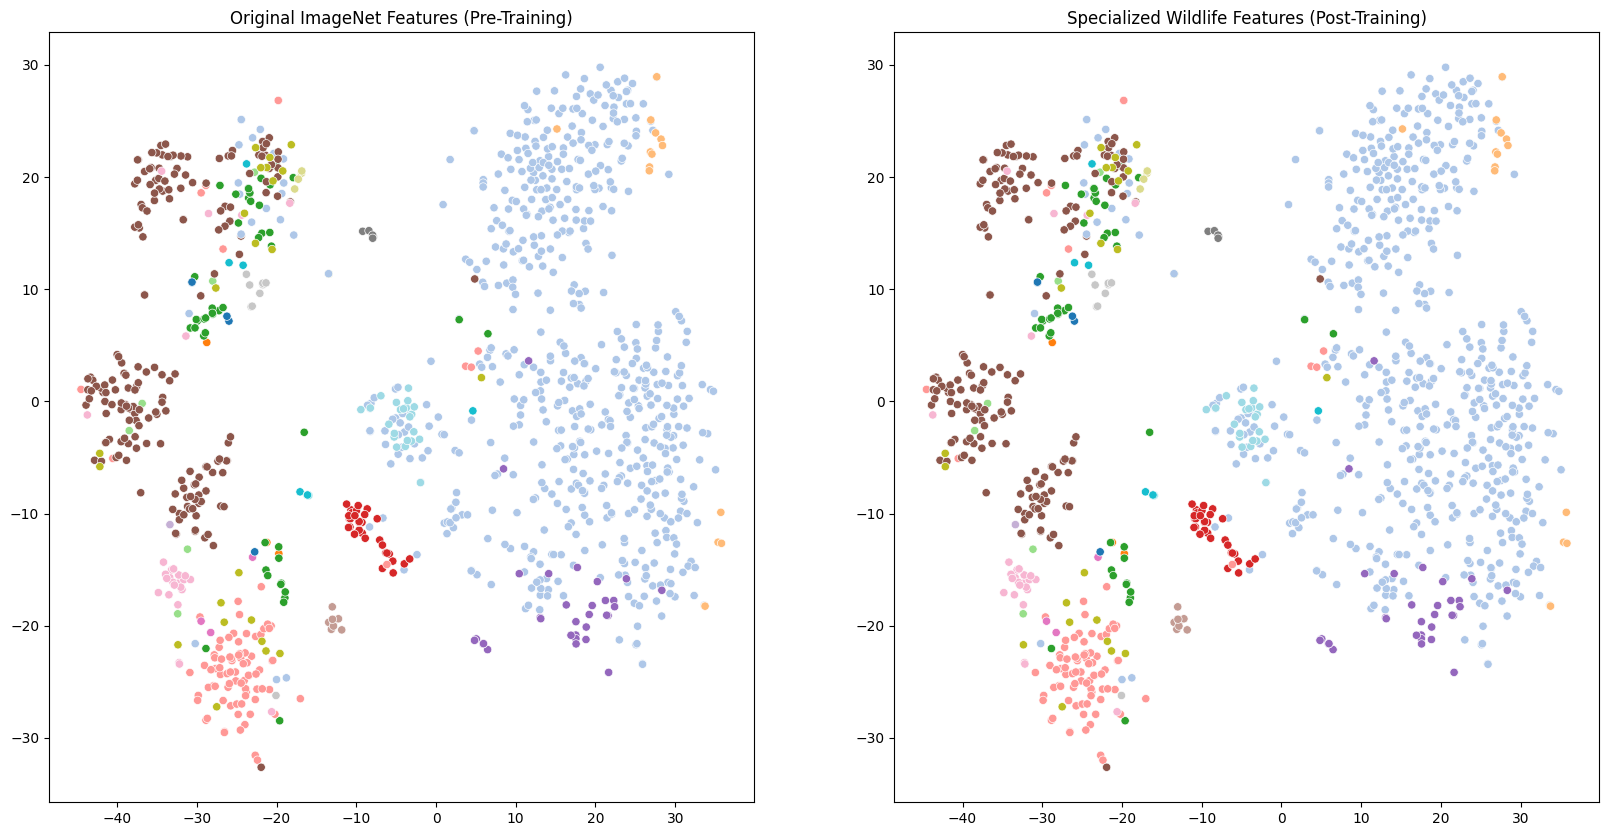

In [85]:
def plot_tsne(data, labels, title):
    reduced = TSNE(n_components=2, random_state=42).fit_transform(data)
    sns.scatterplot(x=reduced[:,0], y=reduced[:,1], hue=labels, palette='tab20', legend=False)
    plt.title(title)

plt.figure(figsize=(20, 10))

# Left side: What the model saw BEFORE you trained it
plt.subplot(1, 2, 1)
plot_tsne(raw_embeddings, y_true_train, "Original ImageNet Features (Pre-Training)")

# Right side: What the model sees NOW
plt.subplot(1, 2, 2)
plot_tsne(custom_embeddings, y_true_train, "Specialized Wildlife Features (Post-Training)")

In [86]:
# 1. Get a weight sample from your trained model
trained_weights = model.get_layer('efficientnetv2-b1').get_weights()[0]

# 2. Load a fresh, untouched base model
fresh_base = tf.keras.applications.EfficientNetV2B1(weights='imagenet', include_top=False)
fresh_weights = fresh_base.get_weights()[0]

# 3. Compare them
diff = np.sum(trained_weights - fresh_weights)

if diff == 0:
    print("CRITICAL: The weights are identical. Your training did not update the base model.")
else:
    print(f"Success: The weights have shifted by {diff:.4f}. The model HAS learned.")

print(trained_weights, fresh_weights)

CRITICAL: The weights are identical. Your training did not update the base model.
[[[[ 4.43263054e-02  2.54186034e-01 -4.92045909e-01  4.20215726e-02
     6.29299939e-01 -7.50527859e-01  4.14683610e-01  3.05702925e-01
    -2.78474446e-02 -9.21343923e-01 -7.73672462e-01  1.21484593e-01
     1.36427954e-01  1.07883781e-01  1.26698518e+00 -1.86653703e-01
     5.29181808e-02 -5.62370084e-02 -9.48576480e-02 -3.08252424e-01
     7.97463119e-01  8.00939083e-01 -4.83397394e-03  9.14230943e-04
    -5.74731469e-01  6.51639402e-01  4.63061869e-01  8.59172046e-01
     1.03223525e-01  9.40173566e-01 -3.75893325e-01 -6.24781311e-01]
   [ 1.31567612e-01  7.68620491e-01 -8.04651678e-01  3.20533291e-03
    -8.48348498e-01 -1.98345160e+00 -3.17168951e-01  6.01395145e-02
     6.49334669e-01 -1.50888586e+00 -1.33499086e+00  7.51201212e-02
     6.39577627e-01 -7.62220979e-01  2.38906074e+00  1.64892413e-02
    -1.79978833e-01  1.99825168e-01  3.90400290e-02  7.10745215e-01
     1.61056018e+00  1.58906209e+

In [87]:
# 1. Save the model in the modern .keras format
# This saves the architecture, weights, and the optimizer state
model.save("models/kalahari_species_model_unbalanced.keras")

# 2. Save your class names to a labels.txt file
# This is crucial for your function to translate numbers back to names
with open("models/labels.txt", "w") as f:
    for s in test_species_names:
        f.write(f"{s}\n")

print("✅ Model and Labels saved to the 'models' folder.")

✅ Model and Labels saved to the 'models' folder.


In [88]:
model_path = os.path.join("models", "kalahari_species_model_unbalanced.keras")
label_path = os.path.join("models", "labels.txt")
manifest_path = os.path.join("animal_crops", "species_ready_manifest.csv")
crops_folder = 'animal_crops'
df = pd.read_csv(manifest_path)

inference_data = tf.keras.utils.image_dataset_from_directory(
    crops_folder,
    label_mode=None, # Important: No labels exist for new data!
    shuffle=False,   # Keep order so it matches your manifest
    image_size=(224, 224), # Must match IMG_SIZE from training
    batch_size=32
)

# 2. Load your Labels into a list
with open(label_path, "r") as f:
    labels = [line.strip() for line in f.readlines()]

# 3. Load your trained Model
custom_model = tf.keras.models.load_model(model_path)

# 2. Get the file paths in the order they were loaded
# This lets you map the prediction back to the filename
file_paths = inference_data.file_paths

# 3. Predict in batches (much faster than one-by-one)
predictions = custom_model.predict(inference_data)

Found 1443 files.
46/46 ━━━━━━━━━━━━━━━━━━━━ 35s 710ms/step


In [89]:
# 4. Process results
species_results = []
for i, pred in enumerate(predictions):
    pred_idx = np.argmax(pred)
    species_results.append({
        "Path": file_paths[i],
        "Species": labels[pred_idx],
        "SpeciesConfidence": np.max(pred)
    })
    
species_df = pd.DataFrame(species_results)
final_df = pd.concat([df, species_df], axis=1)

final_df.head()
output_df = final_df[['Filename', 'Datetime', 'Species', 'SpeciesConfidence']].copy()

# Save to Project Folder
final_csv = os.path.join("KALAHARI_FINAL_ANALYSIS.csv")
output_df.to_csv(final_csv, index=False)


In [ ]:
explainer = GradCAM()

last_conv_layer_name = 'top_conv'

actual_base = model.layers



print(last_conv_layer_name)

# 3. Generate the visualization
# Note: 'model' is your Sequential model, 'img' is your preprocessed input tensor
grid = explainer.explain(
    validation_data=(img, None), 
    model=model, 
    layer_name='dense_2', 
    class_index=3 # Index of the species
)

explainer.save(grid, ".", "grad_cam.png")


top_conv


ValueError: Exception encountered when calling Functional.call().

[1mInvalid input shape for input [[[  0.   0.   0.]
  [  5.   5.   5.]
  [  6.   6.   6.]
  ...
  [  9.   9.   9.]
  [ 13.  13.  13.]
  [ 16.  16.  16.]]

 [[  2.   2.   2.]
  [ 10.  10.  10.]
  [ 15.  15.  15.]
  ...
  [  9.   9.   9.]
  [ 11.  11.  11.]
  [ 11.  11.  11.]]

 [[  4.   4.   4.]
  [ 10.  10.  10.]
  [ 15.  15.  15.]
  ...
  [  9.   9.   9.]
  [  8.   8.   8.]
  [  5.   5.   5.]]

 ...

 [[ 35.  35.  35.]
  [ 36.  36.  36.]
  [ 34.  34.  34.]
  ...
  [112. 112. 112.]
  [115. 115. 115.]
  [117. 117. 117.]]

 [[ 33.  33.  33.]
  [ 32.  32.  32.]
  [ 27.  27.  27.]
  ...
  [119. 119. 119.]
  [117. 117. 117.]
  [117. 117. 117.]]

 [[ 33.  33.  33.]
  [ 30.  30.  30.]
  [ 25.  25.  25.]
  ...
  [122. 122. 122.]
  [117. 117. 117.]
  [116. 116. 116.]]]. Expected shape (None, None, None, 3), but input has incompatible shape (576, 575, 3)[0m

Arguments received by Functional.call():
  • inputs=tf.Tensor(shape=(5

In [104]:
model.layers

[<Sequential name=sequential_6, built=True>,
 <Functional name=efficientnetv2-b1, built=True>,
 <GlobalAveragePooling2D name=global_average_pooling2d_4, built=True>,
 <Dense name=dense_2, built=True>]